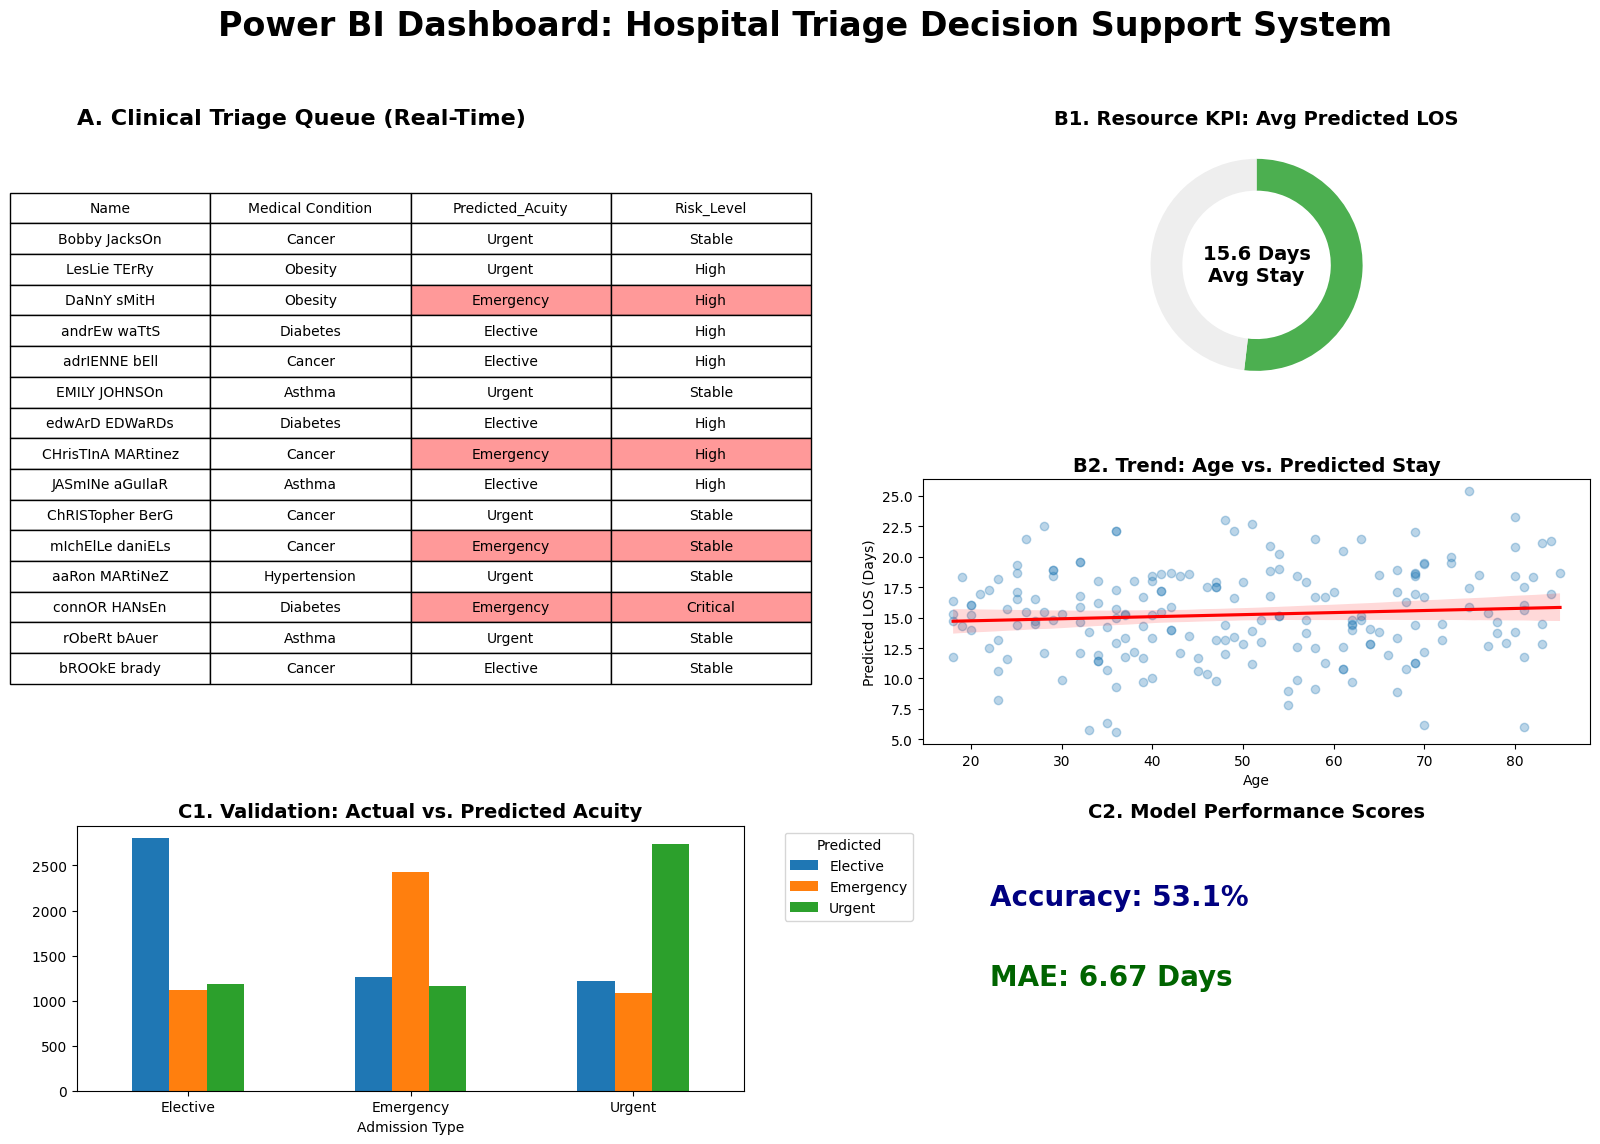

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data generated in the previous step
df = pd.read_csv('Hospital_Triage_PowerBI_Integrated.csv')

# Create a figure for the Dashboard Mockup
fig = plt.figure(figsize=(16, 12))
plt.suptitle('Power BI Dashboard: Hospital Triage Decision Support System', fontsize=24, fontweight='bold', y=0.98)


# A. Clinical Triage Table (Mockup as a styled dataframe plot)
ax1 = plt.subplot2grid((3, 2), (0, 0), rowspan=2)
table_data = df[['Name', 'Medical Condition', 'Predicted_Acuity', 'Risk_Level']].head(15)
ax1.axis('off')
ax1.set_title('A. Clinical Triage Queue (Real-Time)', loc='left', fontsize=16, fontweight='bold')
# Coloring logic for the table
colors = []
for index, row in table_data.iterrows():
    if row['Predicted_Acuity'] == 'Emergency':
        colors.append(['#ffffff', '#ffffff', '#ff9999', '#ff9999']) # Red highlight for Emergency
    else:
        colors.append(['#ffffff', '#ffffff', '#ffffff', '#ffffff'])

the_table = ax1.table(cellText=table_data.values,
                      colLabels=table_data.columns,
                      cellColours=colors,
                      loc='center',
                      cellLoc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.8)

# B. Resource Forecasting: Gauge Chart (Mockup using Pie/Donut)
ax2 = plt.subplot2grid((3, 2), (0, 1))
avg_los = df['Predicted_LOS'].mean()
ax2.pie([avg_los, 30-avg_los], colors=['#4CAF50', '#EEEEEE'], startangle=90, counterclock=False, wedgeprops=dict(width=0.3))
ax2.text(0, 0, f"{avg_los:.1f} Days\nAvg Stay", ha='center', va='center', fontsize=14, fontweight='bold')
ax2.set_title('B1. Resource KPI: Avg Predicted LOS', fontsize=14, fontweight='bold')

# B2. Resource Forecasting: Scatter Plot
ax3 = plt.subplot2grid((3, 2), (1, 1))
sns.regplot(x='Age', y='Predicted_LOS', data=df.sample(200), ax=ax3, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
ax3.set_title('B2. Trend: Age vs. Predicted Stay', fontsize=14, fontweight='bold')
ax3.set_xlabel('Age')
ax3.set_ylabel('Predicted LOS (Days)')

# C. Model Validation: Clustered Bar Chart
ax4 = plt.subplot2grid((3, 2), (2, 0))
comp_df = df.groupby(['Admission Type', 'Predicted_Acuity']).size().unstack(fill_value=0)
comp_df.plot(kind='bar', ax=ax4)
ax4.set_title('C1. Validation: Actual vs. Predicted Acuity', fontsize=14, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(title='Predicted', bbox_to_anchor=(1.05, 1), loc='upper left')

# C2. Model Validation: Metrics Cards
ax5 = plt.subplot2grid((3, 2), (2, 1))
ax5.axis('off')
accuracy = (df['Admission Type'] == df['Predicted_Acuity']).mean() * 100
mae = np.mean(np.abs(df['Actual LOS'] - df['Predicted_LOS']))
ax5.text(0.1, 0.7, f"Accuracy: {accuracy:.1f}%", fontsize=20, color='navy', fontweight='bold')
ax5.text(0.1, 0.4, f"MAE: {mae:.2f} Days", fontsize=20, color='darkgreen', fontweight='bold')
ax5.set_title('C2. Model Performance Scores', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('power_bi_mockup.png')
plt.show()